# Source localization with SESL

This notebook is a modifieed version of MNE's "Source localization with MNE, dSPM, sLORETA, and eLORETA" tutorial, adapted to use the `sesl` (structural eigenmode source localisation) method.   
The aim of this tutorial is to teach you how the functions in `sesl` can fit in a standard MNE workflow.  The modifications will be highlighted with comments.  
The original is available at: https://mne.tools/stable/auto_tutorials/inverse/30_mne_dspm_loreta.html

In [27]:
# Authors: The MNE-Python contributors for original code.  P.H. Siu for modifications.
# License: BSD-3-Clause. 
# Copyright the MNE-Python contributors for original code.  P.H. Siu for modifications.

In [90]:
import matplotlib.pyplot as plt
import numpy as np

import mne
from mne.datasets import sample
from mne.minimum_norm import apply_inverse, make_inverse_operator

# Import sesl functions - Notably, it uses apply_solver over the MNE apply_inverse function
from gem_fns import *
from useful_fns import apply_solver

Process MEG data



In [29]:
data_path = sample.data_path()
raw_fname = data_path / "MEG" / "sample" / "sample_audvis_filt-0-40_raw.fif"

raw = mne.io.read_raw_fif(raw_fname)  # already has an average reference
events = mne.find_events(raw, stim_channel="STI 014")

event_id = dict(aud_l=1)  # event trigger and conditions
tmin = -0.2  # start of each epoch (200ms before the trigger)
tmax = 0.5  # end of each epoch (500ms after the trigger)
raw.info["bads"] = ["MEG 2443", "EEG 053"]  # mark known bad channels
baseline = (None, 0)  # means from the first instant to t = 0
reject = dict(grad=4000e-13, mag=4e-12, eog=150e-6)

epochs = mne.Epochs(
    raw,
    events,
    event_id,
    tmin,
    tmax,
    proj=True,
    picks=("meg", "eog"),
    baseline=baseline,
    reject=reject,
)

Opening raw data file /Users/pokhims/mne_data/MNE-sample-data/MEG/sample/sample_audvis_filt-0-40_raw.fif...
    Read a total of 4 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
        Average EEG reference (1 x 60)  idle
    Range : 6450 ... 48149 =     42.956 ...   320.665 secs
Ready.
319 events found on stim channel STI 014
Event IDs: [ 1  2  3  4  5 32]
Not setting metadata
72 matching events found
Setting baseline interval to [-0.19979521315838786, 0.0] s
Applying baseline correction (mode: mean)
Created an SSP operator (subspace dimension = 3)
3 projection items activated


## Compute regularized noise covariance
For more details see `tut-compute-covariance`.



Loading data for 72 events and 106 original time points ...
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on MAG : ['MEG 1711']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
    Rejecting  epoch based on EOG : ['EOG 061']
17 bad epochs dropped
    Created an SSP operator (subspace dimension = 3)
    Setting small MEG eigenvalues to zero (witho

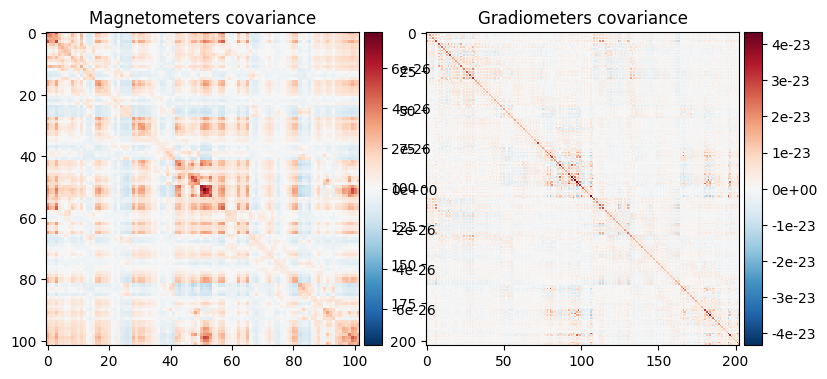

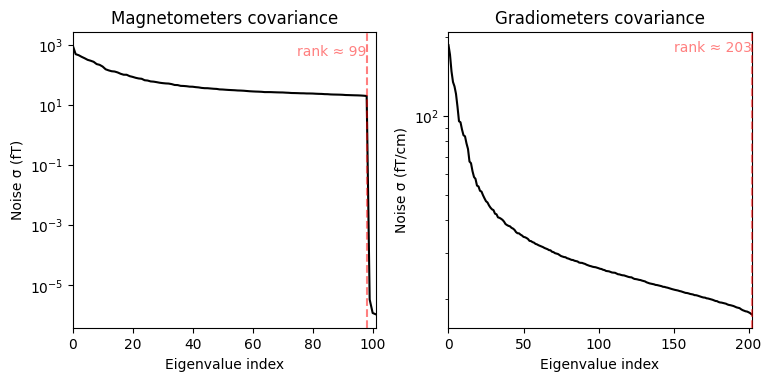

In [30]:
noise_cov = mne.compute_covariance(
    epochs, tmax=0.0, method=["shrunk", "empirical"], rank=None, verbose=True
)

fig_cov, fig_spectra = mne.viz.plot_cov(noise_cov, raw.info)

## Compute the evoked response
Let's just use the MEG channels for simplicity.



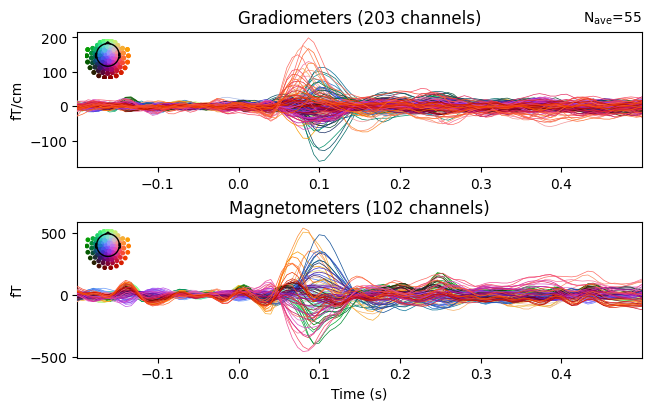

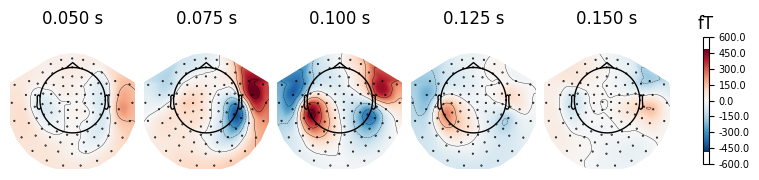

In [31]:
evoked = epochs.average().pick("meg")
evoked.plot(time_unit="s");
evoked.plot_topomap(times=np.linspace(0.05, 0.15, 5), ch_type="mag");

It's also a good idea to look at whitened data:



NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Computing rank from covariance with rank=None
    Using tolerance 1.6e-13 (2.2e-16 eps * 203 dim * 3.5  max singular value)
    Estimated rank (grad): 203
    GRAD: rank 203 computed from 203 data channels with 0 projectors
Computing rank from covariance with rank=None
    Using tolerance 2.2e-14 (2.2e-16 eps * 102 dim * 0.98  max singular value)
    Estimated rank (mag): 99
    MAG: rank 99 computed from 102 data channels with 3 projectors
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank={'grad': 203, 'mag': 99, 'meg': 302}
    Setting small MEG eigenvalues to zero (without PCA)
    Created the whitener using a noise covariance matrix with rank 302 (3 small eigenvalues omitted)


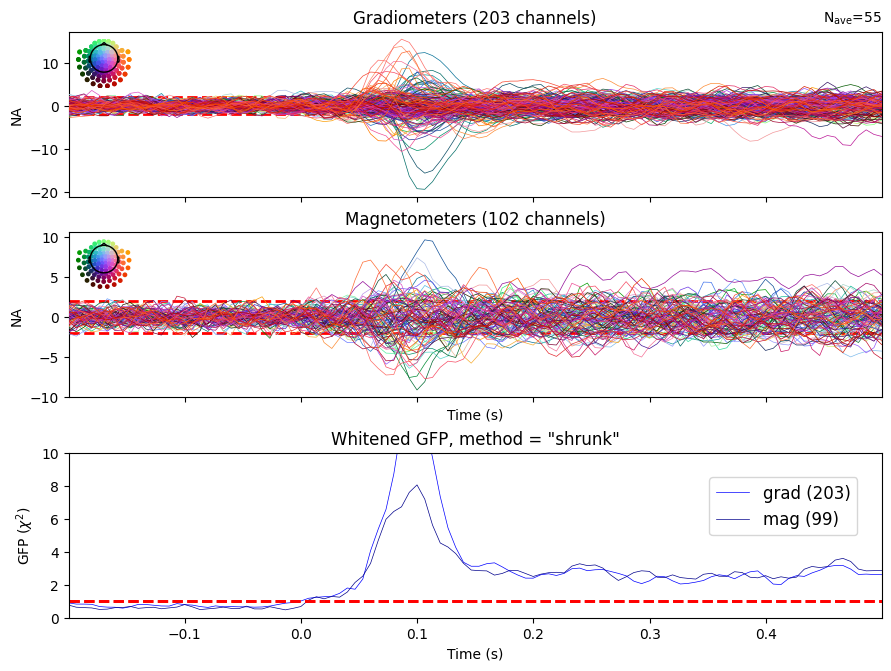

In [32]:
evoked.plot_white(noise_cov, time_unit="s")
del epochs, raw  # to save memory

## Inverse modeling: MNE/dSPM on evoked and raw data
Here we first read the forward solution. You will likely need to compute
one for your own data -- see `tut-forward` for information on how
to do it.



In [33]:
fname_fwd = data_path / "MEG" / "sample" / "sample_audvis-meg-oct-6-fwd.fif"
fwd = mne.read_forward_solution(fname_fwd)

Reading forward solution from /Users/pokhims/mne_data/MNE-sample-data/MEG/sample/sample_audvis-meg-oct-6-fwd.fif...
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    Reading a source space...
    Computing patch statistics...
    Patch information added...
    Distance information added...
    [done]
    2 source spaces read
    Desired named matrix (kind = 3523 (FIFF_MNE_FORWARD_SOLUTION_GRAD)) not available
    Read MEG forward solution (7498 sources, 306 channels, free orientations)
    Source spaces transformed to the forward solution coordinate frame


## Here is where the main difference is from the MNE tutorial.
### For this example we will use the geometric eigenmode approach.

In [ ]:
# Define the subjects directory (normally for Freesurfer, but here it's MNE's sample data directory)
subjects_dir = data_path / "subjects"

In [ ]:
# Mask is used to restrict the source space to the cortical surface, if causing issues, can set to None.
mask = cortical_mask('sample', subjects_dir, fwd['src'])
# mask = None

Reading labels from parcellation...
   read 34 labels from /Users/pokhims/mne_data/MNE-sample-data/subjects/sample/label/lh.aparc.annot
Reading labels from parcellation...
   read 34 labels from /Users/pokhims/mne_data/MNE-sample-data/subjects/sample/label/rh.aparc.annot


In [ ]:
# Calculate the GEMs
evals, emodes = both_hemi_calc_eig(fwd['src'], mask=mask, num_modes=1000)

Downsampling the triangles
Downsampling the triangles
TriaMesh with regular Laplace-Beltrami
Solver: spsolve (LU decomposition) ...
TriaMesh with regular Laplace-Beltrami
Solver: spsolve (LU decomposition) ...


In [ ]:
# Apply weighting
weight = 1 / (2*np.pi + np.sqrt(np.abs(evals)))
emodes = emodes * weight[np.newaxis, :]

In [123]:
# Set some parameters for the solver
loose = 0
depth = 0 
snr = 10.0
rcond = 1/(10**(snr/10)) # rcond is the truncation parameter for the solver which is similar to the regularisation parameter lambda2 in MNE.  May need some tinkering. 

In [124]:
# Apply the solver
solver_kwargs = dict(emodes=emodes, rcond=rcond)
stc, var_exp, w = apply_solver(gem_solver, evoked, fwd, noise_cov, loose, depth, **solver_kwargs)

# For comparison with the MNE original methods, we need to take the absolute value of the estimate - No need to do this if you only want to look at the GEM resuilt.
# Altrnatively, set loose=0 for all methods
# stc.data = np.abs(stc.data)

Converting forward solution to fixed orientation
    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
info["bads"] and noise_cov["bads"] do not match, excluding bad channels from both
Computing inverse operator with 305 channels.
    305 out of 306 channels remain after picking
Selected 305 channels
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank=None
    Using tolerance 2.9e-13 (2.2e-16 eps * 305 dim * 4.3  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
    Explained 100.0% variance


In [125]:
# Can compare with MNE original methods
inverse_operator = make_inverse_operator(
    evoked.info, fwd, noise_cov, loose=loose, depth=depth
)

method = "dSPM"  # could choose MNE, sLORETA, or eLORETA instead
lambda2 = 1.0 / snr**2
stc_mne, residual = apply_inverse(
    evoked,
    inverse_operator,
    lambda2,
    method=method,
    pick_ori=None,
    return_residual=True,
    verbose=True,
)

info["bads"] and noise_cov["bads"] do not match, excluding bad channels from both
Computing inverse operator with 305 channels.
    305 out of 306 channels remain after picking
Selected 305 channels
    Average patch normals will be employed in the rotation to the local surface coordinates....
    Converting to surface-based source orientations...
    [done]
Whitening the forward solution.
    Created an SSP operator (subspace dimension = 3)
Computing rank from covariance with rank=None
    Using tolerance 2.9e-13 (2.2e-16 eps * 305 dim * 4.3  max singular value)
    Estimated rank (mag + grad): 302
    MEG: rank 302 computed from 305 data channels with 3 projectors
    Setting small MEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing SVD of whitened and weighted lead field matrix.
    largest singular value = 4.83499
    scaling factor to adjust the trace = 1.03726e+20 (nchan = 305 nzero = 3)
Preparing the inverse o

## Visualization
We can look at different dipole activations:



[Text(0.5, 0, 'time (ms)'), Text(0, 0.5, 'value')]

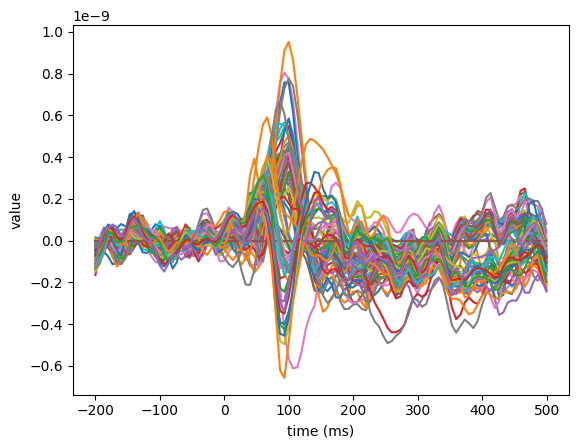

In [126]:
fig, ax = plt.subplots()
ax.plot(1e3 * stc.times, stc.data[::100, :].T)
ax.set(xlabel="time (ms)", ylabel=f"value")

Examine the original data and the residual after fitting:



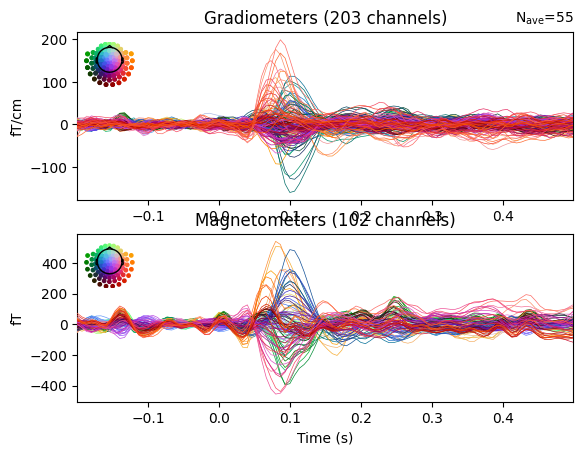

In [127]:
fig, axes = plt.subplots(2, 1)
evoked.plot(axes=axes)
for ax in axes:
    for text in list(ax.texts):
        text.remove()
    for line in ax.lines:
        line.set_color("#98df81")

Here we use peak getter to move visualization to the time point of the peak
and draw a marker at the maximum peak vertex.



In [128]:
vertno_max, time_max = stc.get_peak(hemi="rh")

subjects_dir = data_path / "subjects"
surfer_kwargs = dict(
    hemi="rh",
    subjects_dir=subjects_dir,
    # clim=dict(kind="value", lims=[8, 12, 15]),
    views="lateral",
    initial_time=time_max,
    time_unit="s",
    size=(800, 800),
    smoothing_steps=10,
    # transparent=False,
)
brain = stc.plot(**surfer_kwargs)
brain.add_foci(
    vertno_max,
    coords_as_verts=True,
    hemi="rh",
    color="blue",
    scale_factor=0.6,
    alpha=0.5,
)
brain.add_text(
    0.1, 0.9, "GEM (plus location of maximal activation)", "title", font_size=14
)

# The documentation website's movie is generated with:
# brain.save_movie(..., tmin=0.05, tmax=0.15, interpolation='linear',
#                  time_dilation=20, framerate=10, time_viewer=True)

Using control points [2.84262374e-10 3.32626878e-10 7.27836459e-10]
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`
For automatic theme detection, "darkdetect" has to be installed! You can install it with `pip install darkdetect`


Context leak detected, msgtracer returned -1


There are many other ways to visualize and work with source data, see
for example:

- `tut-viz-stcs`
- `ex-morph-surface`
- `ex-morph-volume`
- `ex-vector-mne-solution`
- `tut-dipole-orientations`
- `tut-mne-fixed-free`
- `examples using apply_inverse
  <sphx_glr_backreferences_mne.minimum_norm.apply_inverse>`.

